# Real World Classification

## Load data

Import the necessary libraries

In [ ]:
# If you do not use colab. You should install these packages.
# !pip install numpy
# !pip install pandas
# !pip install matplotlib
# !pip install scikit-learn
# !pip install graphviz

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

seed=40
np.random.seed(seed)

load the data

In [ ]:
# Load data from the regularization demo CSV
df = pd.read_csv('data/NYCU_Iris.csv')
df.head()

In [ ]:
cols_with_nan = df.columns[df.isnull().any()]

cols_with_nan = [
    col for col in cols_with_nan
    if df[col].isnull().sum() < len(df)
]

for col in cols_with_nan:
    print(col)
    print("Median:", df[col].median())
    print("Std:", df[col].std())
    print()

In [ ]:
from sklearn.impute import KNNImputer

df_numeric = df.select_dtypes(include=[np.number])

df_numeric = df_numeric.drop(columns=[
    col for col in df_numeric.columns if df_numeric[col].isnull().sum() == len(df_numeric)
])

# KNN Imputer
imputer = KNNImputer(n_neighbors=5)

df_imputed = pd.DataFrame(
    imputer.fit_transform(df_numeric),
    columns=df_numeric.columns
)

for col in df_imputed.columns:
    if col in cols_with_nan:
        print(col)
        print("Median:", df_imputed[col].median())
        print("Std:", df_imputed[col].std())
        print()

## Data Preprocessing

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer

def data_preprocessing(df):
    # transform label to bi-class
    df['Species'] = df['Species'].astype(str).str.strip()
    le = LabelEncoder()
    df['Species'] = le.fit_transform(df['Species'])

    feature_cols = [c for c in df.columns if c not in ['Id', 'Species']]

    # transform string to number
    for col in feature_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # TODO: Replace the missing values using “Nearest Neighbors Imputation”
    # ---------- Start your code below ----------

    
    # ---------- --------------------- ----------
     
    return df, feature_cols

df, feature_cols = data_preprocessing(df)

In [ ]:
df.describe()

## Data Exploration

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df_imputed['PetalWidthCm'], bins=20)
plt.title('Histogram of PetalWidthCm')
plt.xlabel('PetalWidthCm')
plt.ylabel('Frequency')
plt.show()

In [ ]:
from sklearn.feature_selection import r_regression
import numpy as np

#Zielvariable
y = df_imputed['PetalWidthCm']

#Features ohne die ausgeschlossenen Spalten
X = df_imputed.drop(columns=['PetalWidthCm', 'Species', 'Id'], errors='ignore')

#Pearson correlations
corr = r_regression(X, y)

# Bestes Feature finden
best_idx = np.argmax(corr)
best_feature = X.columns[best_idx]
best_value = corr[best_idx]

print(best_feature, best_value)

In [ ]:
#negative correlations sortieren
sorted_idx = np.argsort(corr)  # aufsteigend

#Top 5 negative
neg_idx = sorted_idx[:5]

for i in neg_idx:
    print(X.columns[i], corr[i])

In [ ]:
import matplotlib.pyplot as plt

features = [
    'PetalWidthCompactness',
    'SepalWidthMajorAxis',
    'SepalGlossIndex',
    'SepalWidthCompactness',
    'SepalWidthCurvature',
    'SepalWidthMinorAxis'
]

plt.figure(figsize=(10,6))
df_imputed[features].boxplot()
plt.title('Boxplot of Selected Features')
plt.xticks(rotation=45)
plt.show()

In [ ]:
from sklearn.feature_selection import r_regression

# TODO: Complete the 4. Data Exploration

## Model Training

### Prepare the data

In [ ]:
from sklearn.model_selection import train_test_split

# Features aus dem imputierten numerischen DataFrame
X = df_imputed[feature_cols].values.astype(float)

# Target aus dem ursprünglichen DataFrame
y = df['Species'].values

# Falls Species Strings sind und du eine binäre Klassifikation brauchst:
classes = sorted(pd.Series(y).unique())
print("Classes:", classes)

y = (pd.Series(y) == classes[1]).astype(int).values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=seed
)

In [ ]:
from model.linear_model import LinearModel
from model.metrics import logloss
from model.gradients import logloss_sigmoid_grad
from model.activations import sigmoid

loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

In [ ]:
#Q1
from sklearn.model_selection import KFold, cross_val_score
import pandas as pd
import numpy as np

learning_rates = [0.005, 0.01, 0.1, 0.5]
reg_lambdas = [1.0, 2.0, 4.0, 8.0]

cv = KFold(n_splits=5, shuffle=True, random_state=40)

cv_results = pd.DataFrame(index=learning_rates, columns=reg_lambdas)

for lr in learning_rates:
    for reg_lambda in reg_lambdas:
        model = LinearModel(
            dim=X_train.shape[1],
            is_reg=False,
            loss_fn=loss_fn,
            act_fn=act_fn,
            grad_fn=grad_fn,
            lr=lr,
            reg_type='l2',
            reg_lambda=reg_lambda,
            n_iteration=1000,   
            val_ratio=0.2,
            random_state=seed,
            verbose=False,
            plot_curve=False
        )

        scores = cross_val_score(
            model,
            X_train,
            y_train,
            cv=cv,
            scoring='accuracy'
        )

        cv_results.loc[lr, reg_lambda] = scores.mean()

cv_results

In [ ]:
top_2_params = [
    {"lr": 0.005, "reg_lambda": 1.0},
    {"lr": 0.005, "reg_lambda": 2.0},
]

for params in top_2_params:
    print(f"Testing model with lr={params['lr']}, reg_lambda={params['reg_lambda']}")

    model = LinearModel(
        dim=X_train.shape[1],
        is_reg=False,
        loss_fn=loss_fn,
        act_fn=act_fn,
        grad_fn=grad_fn,
        lr=params["lr"],
        reg_type="l2",
        reg_lambda=params["reg_lambda"],
        n_iteration=1000,
        val_ratio=0.2,
        random_state=seed,
        verbose=False,
        plot_curve=False
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    evaluate_binary_classifier(y_test, y_pred)
    print()

In [ ]:
print("X_train has NaN:", np.isnan(X_train).any())
print("y_train unique:", np.unique(y_train))

In [1]:
# Question 2 - SVM
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score

In [2]:
df = pd.read_csv("mobile_price.csv")

df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [ ]:
X = df.drop("price_range", axis=1)
y = df["price_range"]

In [ ]:
# First split: 60% train, 40% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.4,
    random_state=42,
    shuffle=True
)

# Second split: 20% validation, 20% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    shuffle=True
)

print("Train size:", X_train.shape)
print("Validation size:", X_val.shape)
print("Test size:", X_test.shape)

In [ ]:
svm_model = SVC(C=1.0, random_state=42)

svm_model.fit(X_train, y_train)

In [ ]:
y_train_pred = svm_model.predict(X_train)
y_val_pred = svm_model.predict(X_val)
y_test_pred = svm_model.predict(X_test)

In [ ]:
print("Training Performance")
print("Accuracy:", accuracy_score(y_train, y_train_pred))
print("F1-score:", f1_score(y_train, y_train_pred, average='weighted'))

print()

print("Validation Performance")
print("Accuracy:", accuracy_score(y_val, y_val_pred))
print("F1-score:", f1_score(y_val, y_val_pred, average='weighted'))

print()

print("Testing Performance")
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("F1-score:", f1_score(y_test, y_test_pred, average='weighted'))

In [ ]:
C_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000]

In [ ]:
results = []

for C in C_values:
    svm_model = SVC(C=C, random_state=42)

    svm_model.fit(X_train, y_train)

    y_train_pred = svm_model.predict(X_train)
    y_val_pred = svm_model.predict(X_val)
    y_test_pred = svm_model.predict(X_test)

    results.append({
        "C": C,

        "train_acc": accuracy_score(y_train, y_train_pred),
        "val_acc": accuracy_score(y_val, y_val_pred),
        "test_acc": accuracy_score(y_test, y_test_pred),

        "train_f1": f1_score(y_train, y_train_pred, average='weighted'),
        "val_f1": f1_score(y_val, y_val_pred, average='weighted'),
        "test_f1": f1_score(y_test, y_test_pred, average='weighted')
    })

results_df = pd.DataFrame(results)

results_df

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(results_df["C"], results_df["train_acc"], marker='o', label='Train Accuracy')
plt.plot(results_df["C"], results_df["val_acc"], marker='o', label='Validation Accuracy')
plt.plot(results_df["C"], results_df["test_acc"], marker='o', label='Test Accuracy')

plt.xscale('log')

plt.xlabel("C value")
plt.ylabel("Accuracy")
plt.title("SVM Accuracy for Different C Values")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(results_df["C"], results_df["train_f1"], marker='o', label='Train F1-score')
plt.plot(results_df["C"], results_df["val_f1"], marker='o', label='Validation F1-score')
plt.plot(results_df["C"], results_df["test_f1"], marker='o', label='Test F1-score')

plt.xscale('log')

plt.xlabel("C value")
plt.ylabel("F1-score")
plt.title("SVM F1-score for Different C Values")

plt.legend()
plt.grid(True)

plt.show()

In [3]:
#  Question 3 Association Rule Mining 
filtered_df = df[df["price_range"] == 1]

filtered_df.shape

(500, 21)

In [4]:
selected_features = [
    "ram",
    "int_memory",
    "px_width",
    "battery_power"
]

filtered_df = filtered_df[selected_features]

filtered_df.head()

,ram,int_memory,px_width,battery_power
0,2549,7,756,842
4,1411,44,1212,1821
5,1067,22,1654,1859
12,1482,33,748,1815
18,1835,49,878,1131


In [5]:
def categorize_feature(value, min_val, max_val):
    value_range = max_val - min_val

    low_threshold = min_val + 0.3 * value_range
    medium_threshold = min_val + 0.7 * value_range

    if value <= low_threshold:
        return "low"
    elif value <= medium_threshold:
        return "medium"
    else:
        return "high"

In [6]:
categorized_df = pd.DataFrame()

for feature in selected_features:
    min_val = filtered_df[feature].min()
    max_val = filtered_df[feature].max()

    categorized_df[feature] = filtered_df[feature].apply(
        lambda x: categorize_feature(x, min_val, max_val)
    )

categorized_df.head()

,ram,int_memory,px_width,battery_power
0,high,low,low,low
4,medium,medium,medium,high
5,low,medium,high,high
12,medium,medium,low,high
18,medium,high,low,medium


In [7]:
transactions = categorized_df.apply(
    lambda row: [
        f"ram_{row['ram']}",
        f"int_memory_{row['int_memory']}",
        f"px_width_{row['px_width']}",
        f"battery_power_{row['battery_power']}"
    ],
    axis=1
)

transactions.head()

0     [ram_high, int_memory_low, px_width_low, batte...
4     [ram_medium, int_memory_medium, px_width_mediu...
5     [ram_low, int_memory_medium, px_width_high, ba...
12    [ram_medium, int_memory_medium, px_width_low, ...
18    [ram_medium, int_memory_high, px_width_low, ba...
dtype: object

In [8]:
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()

te_array = te.fit(transactions).transform(transactions)

transaction_df = pd.DataFrame(te_array, columns=te.columns_)

transaction_df.head()

,battery_power_high,battery_power_low,battery_power_medium,int_memory_high,int_memory_low,int_memory_medium,px_width_high,px_width_low,px_width_medium,ram_high,ram_low,ram_medium
0,False,True,False,False,True,False,False,True,False,True,False,False
1,True,False,False,False,False,True,False,False,True,False,False,True
2,True,False,False,False,False,True,True,False,False,False,True,False
3,True,False,False,False,False,True,False,True,False,False,False,True
4,False,False,True,True,False,False,False,True,False,False,False,True


In [9]:
from mlxtend.frequent_patterns import fpgrowth

frequent_itemsets = fpgrowth(
    transaction_df,
    min_support=0.3,
    use_colnames=True
)

frequent_itemsets = frequent_itemsets.sort_values(
    by="support",
    ascending=False
)

frequent_itemsets

,support,itemsets
2,0.682,frozenset({ram_medium})
3,0.416,frozenset({px_width_medium})
5,0.414,frozenset({battery_power_medium})
4,0.412,frozenset({int_memory_medium})
7,0.318,"frozenset({battery_power_medium, ram_medium})"
0,0.316,frozenset({int_memory_low})
1,0.308,frozenset({battery_power_low})
6,0.306,"frozenset({px_width_medium, ram_medium})"


In [10]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.4
)

rules = rules[
    (rules["support"] >= 0.3) &
    (rules["confidence"] >= 0.4) &
    (rules["lift"] >= 0.8)
]

rules = rules.sort_values(
    by="confidence",
    ascending=False
)

rules[[
    "antecedents",
    "consequents",
    "support",
    "confidence",
    "lift"
]]

,antecedents,consequents,support,confidence,lift
0,frozenset({battery_power_medium}),frozenset({ram_medium}),0.318,0.768116,1.126270
2,frozenset({px_width_medium}),frozenset({ram_medium}),0.306,0.735577,1.078559
1,frozenset({ram_medium}),frozenset({battery_power_medium}),0.318,0.466276,1.126270
3,frozenset({ram_medium}),frozenset({px_width_medium}),0.306,0.448680,1.078559


In [11]:
# Question 4 PCA and K-Means
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

import matplotlib.pyplot as plt

In [12]:
X = df.drop("price_range", axis=1)
y = df["price_range"]

In [13]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled.shape

(2000, 20)

In [14]:
#PCA durchfuehren
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

X_pca.shape

(2000, 2)

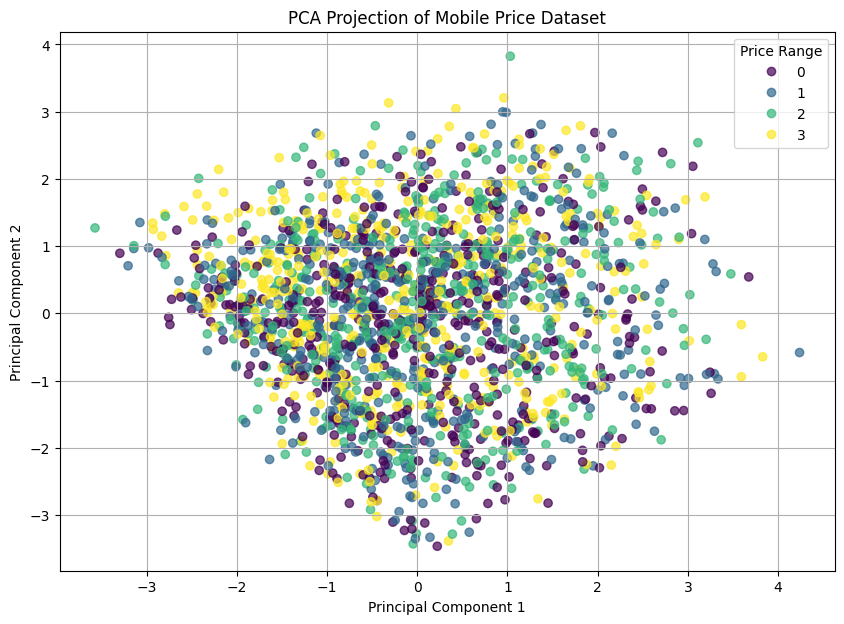

In [15]:
#scatterplot
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y,
    cmap='viridis',
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection of Mobile Price Dataset")

plt.legend(*scatter.legend_elements(), title="Price Range")

plt.grid(True)

plt.show()

In [16]:
#KMeans auf allen Features
kmeans_full = KMeans(
    n_clusters=4,
    random_state=42
)

clusters_full = kmeans_full.fit_predict(X_scaled)

clusters_full[:10]

array([0, 2, 2, 2, 1, 2, 3, 3, 3, 2], dtype=int32)

In [17]:
#ARI berechnen
ari_full = adjusted_rand_score(y, clusters_full)

print("ARI Score (Full Features):", ari_full)

ARI Score (Full Features): 0.006067417030597427


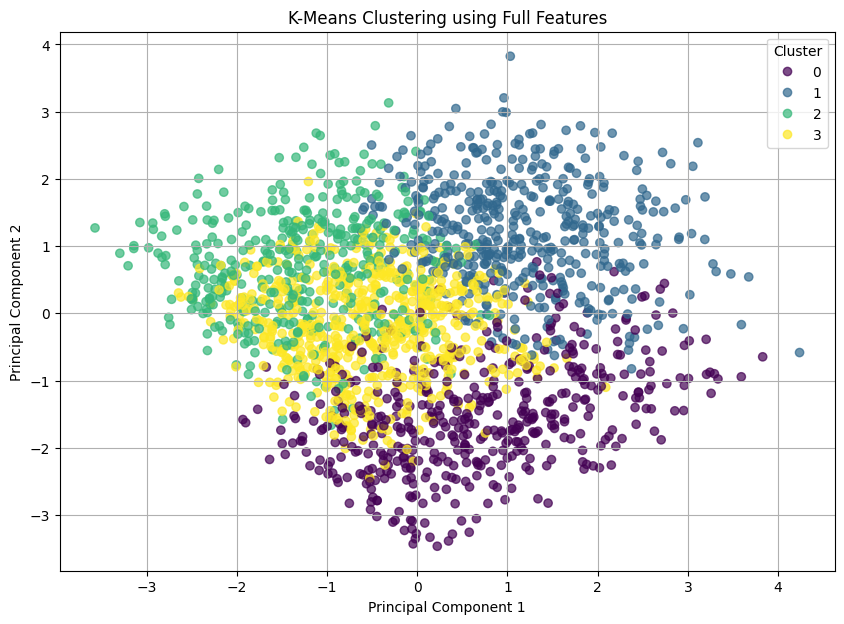

In [18]:
#Clusterplot für Full Features
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters_full,
    cmap='viridis',
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clustering using Full Features")

plt.legend(*scatter.legend_elements(), title="Cluster")

plt.grid(True)

plt.show()

In [19]:
#KMeans auf PCA-Daten
kmeans_pca = KMeans(
    n_clusters=4,
    random_state=42
)

clusters_pca = kmeans_pca.fit_predict(X_pca)

clusters_pca[:10]

array([0, 2, 2, 2, 1, 2, 1, 2, 0, 2], dtype=int32)

In [20]:
#ARI berechnen
ari_pca = adjusted_rand_score(y, clusters_pca)

print("ARI Score (PCA Features):", ari_pca)

ARI Score (PCA Features): 0.00043825468532816857


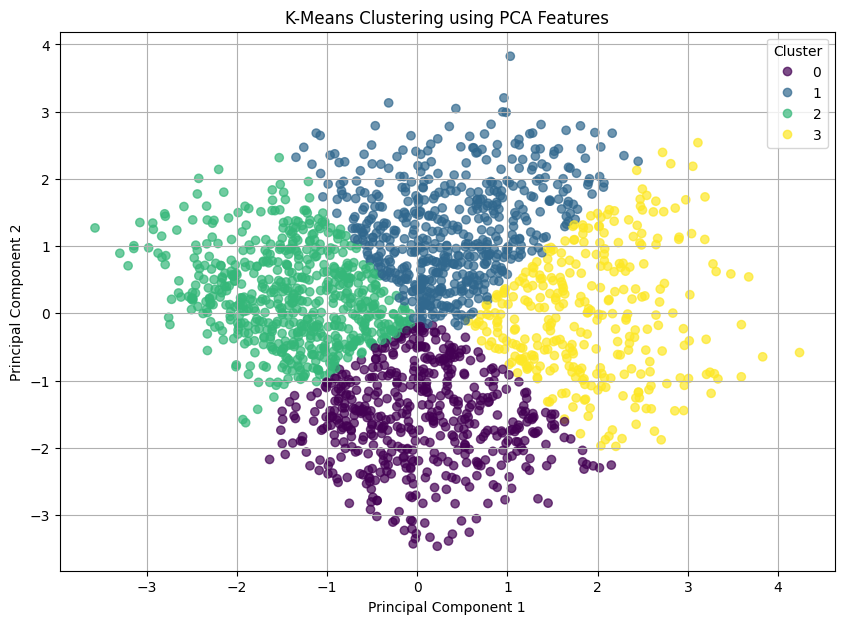

In [21]:
#PCA Clusterplot
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters_pca,
    cmap='viridis',
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clustering using PCA Features")

plt.legend(*scatter.legend_elements(), title="Cluster")

plt.grid(True)

plt.show()

In [22]:
# Question 5 Enhancing K-means Clustering with Association Rule Mining
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

from scipy.stats import mode

In [23]:
def map_clusters_to_labels(cluster_labels, true_labels):
    mapped_labels = np.zeros_like(cluster_labels)

    for cluster in np.unique(cluster_labels):
        mask = (cluster_labels == cluster)

        most_common = mode(true_labels[mask], keepdims=True).mode[0]

        mapped_labels[mask] = most_common

    return mapped_labels

In [24]:
# seeds definieren
seeds = [0, 10, 42, 100, 999]

In [25]:
# original Kmeans evaluieren
original_results = []

for seed in seeds:

    kmeans = KMeans(
        n_clusters=4,
        random_state=seed
    )

    clusters = kmeans.fit_predict(X_scaled)

    predicted_labels = map_clusters_to_labels(clusters, y.values)

    original_results.append({
        "seed": seed,

        "accuracy": accuracy_score(y, predicted_labels),

        "precision": precision_score(
            y,
            predicted_labels,
            average='weighted'
        ),

        "recall": recall_score(
            y,
            predicted_labels,
            average='weighted'
        ),

        "f1": f1_score(
            y,
            predicted_labels,
            average='weighted'
        )
    })

original_results_df = pd.DataFrame(original_results)

original_results_df

C:\Users\janat\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\janat\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\janat\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_clas

,seed,accuracy,precision,recall,f1
0,0,0.2830,0.214979,0.2830,0.234355
1,10,0.2830,0.214915,0.2830,0.234473
2,42,0.3000,0.229570,0.3000,0.246836
3,100,0.2905,0.220678,0.2905,0.239921
4,999,0.2990,0.228859,0.2990,0.245841


In [26]:
# Feature Weighting
X_weighted = X_scaled.copy()

feature_names = X.columns.tolist()

feature_weights = {
    "ram": 2.0,
    "battery_power": 1.5,
    "px_width": 1.5
}

for feature, weight in feature_weights.items():

    idx = feature_names.index(feature)

    X_weighted[:, idx] *= weight

print("Feature weighting applied.")

Feature weighting applied.


In [27]:
#Improved KMeans evaluieren
improved_results = []

for seed in seeds:

    kmeans = KMeans(
        n_clusters=4,
        random_state=seed
    )

    clusters = kmeans.fit_predict(X_weighted)

    predicted_labels = map_clusters_to_labels(clusters, y.values)

    improved_results.append({
        "seed": seed,

        "accuracy": accuracy_score(y, predicted_labels),

        "precision": precision_score(
            y,
            predicted_labels,
            average='weighted'
        ),

        "recall": recall_score(
            y,
            predicted_labels,
            average='weighted'
        ),

        "f1": f1_score(
            y,
            predicted_labels,
            average='weighted'
        )
    })

improved_results_df = pd.DataFrame(improved_results)

improved_results_df

,seed,accuracy,precision,recall,f1
0,0,0.5495,0.553914,0.5495,0.551304
1,10,0.5295,0.528874,0.5295,0.529164
2,42,0.5385,0.538186,0.5385,0.538209
3,100,0.5510,0.555649,0.5510,0.552801
4,999,0.5455,0.548618,0.5455,0.546653


In [28]:
# Durchscnittswerte berechnen
original_avg = original_results_df.mean(numeric_only=True)

improved_avg = improved_results_df.mean(numeric_only=True)

comparison_df = pd.DataFrame({
    "Original KMeans": original_avg,
    "Improved Method": improved_avg
})

comparison_df

,Original KMeans,Improved Method
seed,230.200000,230.200000
accuracy,0.291100,0.542800
precision,0.221800,0.545048
recall,0.291100,0.542800
f1,0.240285,0.543626


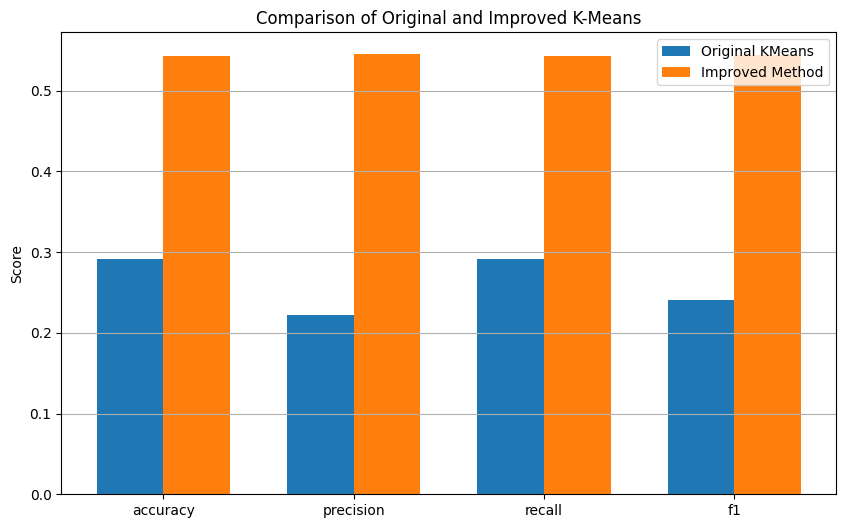

In [29]:
# Balkendiagramm Vergleich
metrics = ["accuracy", "precision", "recall", "f1"]

original_means = [
    original_results_df[m].mean()
    for m in metrics
]

improved_means = [
    improved_results_df[m].mean()
    for m in metrics
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width/2,
    original_means,
    width,
    label="Original KMeans"
)

plt.bar(
    x + width/2,
    improved_means,
    width,
    label="Improved Method"
)

plt.xticks(x, metrics)

plt.ylabel("Score")
plt.title("Comparison of Original and Improved K-Means")

plt.legend()

plt.grid(True, axis='y')

plt.show()

### Train the model!

In [ ]:
# Use the LinearModel to fit the data

from model.linear_model import LinearModel
from model.metrics import logloss
from model.gradients import logloss_sigmoid_grad
from model.utils import *
from model.activations import sigmoid

# Model configuration
loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

np.random.seed(seed)
model = LinearModel(dim=X_train.shape[1], is_reg=False, loss_fn=loss_fn, act_fn=act_fn, grad_fn=grad_fn)
model.fit(X_train, y_train, lr=0.1, n_iteration=10000, val_ratio=0.2, reg_type='', reg_lambda=0)

# print model parameters
print("Model parameters (weights):", model.W)
# sum of absolute values of weights
print("Sum of absolute values of weights:", np.sum(np.abs(model.W)))

## Metrics

In [ ]:
# use evaluate_binary_classifier to evaluate the model on the test set
from model.metrics import evaluate_binary_classifier

y_pred = model.predict(X_test)
evaluate_binary_classifier(y_test, y_pred)